# 13 - 1D CNN Autoencoder Baseline

Symmetric 1D-CNN autoencoder. Encoder: Conv1D + MaxPool1D halves the time
axis twice (100 → 50 → 25) and compresses to 8 channels at the bottleneck.
Decoder mirrors this with UpSampling1D and a final linear Conv1D for
reconstruction.

**Inputs**: arrays from `data/processed/` (run `run_preprocessing()`)<br>
**Outputs**: `models/cnn_ae.keras`

Pipeline parallel to NB 12 (LSTM-AE) so the two non-linear baselines are
directly comparable; comparison to NB 11 (PCA) is the linear-vs-non-linear
axis on the same test_intern split.

## Retrain 


In [ ]:
# Retrain -> load the model from disk & do everything from step 3 - Score Val + test_intern
#model = load_model(MODELS_DIR / 'cnn_ae.keras')

""" def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)

model  = load_model(MODELS_DIR / 'cnn_ae.keras')
scorer = ZNormAdapter(model)
print('Model loaded from disk') """

Model loaded from disk


## 0 - Setup & Imports

In [1]:
import sys, json, time, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

from sentinel.ml_logic.scoring    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, corrected_event_f05, row_precision_recall,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)

tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
MODELS_DIR      = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'FIT_SIZE = {FIT_SIZE!r}')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FIT_SIZE = 50000


---
## 1 - Load Preprocessed Arrays

In [2]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

WIN    = cfg['window_size']
N_FEAT = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')
val_scaled  = np.load(PROCESSED_DIR / 'val_scaled.npy')
y_val       = np.load(PROCESSED_DIR / 'y_val.npy')
test_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_test      = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'X_train_nom      : {X_train_nom.shape}')
print(f'val_scaled       : {val_scaled.shape}   ({int(y_val.sum()):>7,} anom rows)')
print(f'test_intern      : {test_scaled.shape}   ({int(y_test.sum()):>7,} anom rows)')

X_train_nom      : (92271, 100, 58)
val_scaled       : (2232277, 58)   (246,463 anom rows)
test_intern      : (2186220, 58)   (214,961 anom rows)


---
## 2 - Build and Train CNN-AE

Symmetric Conv1D autoencoder: two MaxPool stages (100 → 50 → 25) with a
bottleneck of 8 channels at the smallest spatial resolution. Adam `lr=1e-3`,
MSE loss, EarlyStopping + ReduceLROnPlateau. Per-window z-normalisation
before the forward pass - same drift-robust recipe as NB 12.

In [4]:
def build_cnn_ae(window_size, n_channels):
    inputs = layers.Input(shape=(window_size, n_channels))

    # Encoder: 100 → 50 → 25
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(16, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D( 8, 3, activation='relu', padding='same')(x)   # bottleneck

    # Decoder: 25 → 50 → 100
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    outputs = layers.Conv1D(n_channels, 7, activation='linear', padding='same')(x)

    model = Model(inputs, outputs, name='cnn_ae_bootcamp')
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model


def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


model = build_cnn_ae(WIN, N_FEAT)
model.summary()

Model: "cnn_ae_bootcamp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 32)        │        13,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 16)         │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 58)        │        13,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,034 (125.13 KB)

 Trainable params: 32,034 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
if FIT_SIZE is not None and FIT_SIZE < len(X_train_nom):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
    X_fit_raw = X_train_nom[idx]
    print(f'Training on {len(X_fit_raw):,} subsampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit_raw = X_train_nom
    print(f'Training on all {len(X_fit_raw):,} nominal windows')

X_fit = zscore_window(X_fit_raw)
del X_fit_raw

EPOCHS     = 50
BATCH_SIZE = 256
MODEL_PATH = MODELS_DIR / 'cnn_ae.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=0),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
print(f'Trained in {train_seconds/60:.1f} min  ({len(history.history["loss"])} epochs)')
print(f'Model saved → {MODEL_PATH}')

Training on 50,000 subsampled windows (FIT_SIZE=50,000)
Epoch 1/50
176/176 - 21s - 120ms/step - loss: 0.8230 - val_loss: 0.7776 - learning_rate: 0.0010
Epoch 2/50
176/176 - 19s - 106ms/step - loss: 0.7569 - val_loss: 0.7423 - learning_rate: 0.0010
Epoch 3/50
176/176 - 18s - 104ms/step - loss: 0.7341 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 4/50
176/176 - 18s - 101ms/step - loss: 0.7221 - val_loss: 0.7167 - learning_rate: 0.0010
Epoch 5/50
176/176 - 18s - 105ms/step - loss: 0.7125 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 6/50
176/176 - 19s - 109ms/step - loss: 0.7059 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 7/50
176/176 - 19s - 110ms/step - loss: 0.7017 - val_loss: 0.7001 - learning_rate: 0.0010
Epoch 8/50
176/176 - 19s - 107ms/step - loss: 0.6986 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 9/50
176/176 - 19s - 106ms/step - loss: 0.6964 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 10/50
176/176 - 19s - 111ms/step - loss: 0.6948 - val_loss: 0.6940 - learn

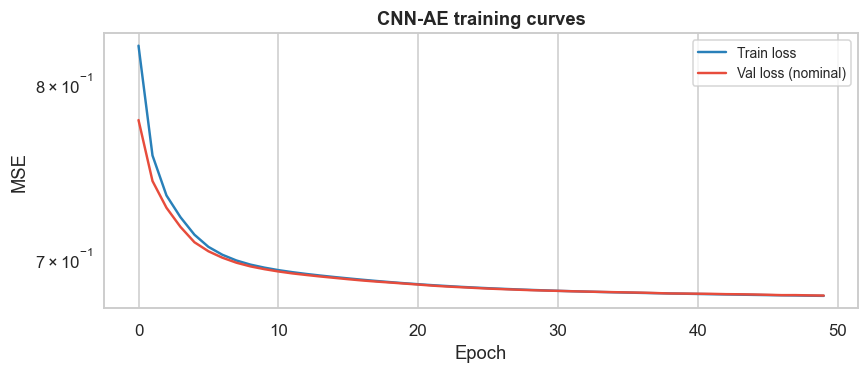

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('CNN-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 - Score Val + test_intern

Same z-normalisation adapter as NB 12: wrap the model so `score_windows` sees
a reconstruction-that-yields-z-space-residual.

Scoring uses `topk=5`: per-window MSE is the mean of the **5 worst-reconstructed
channels** (out of 58) instead of the mean over all channels. Anomalies tend to
affect only a handful of channels; averaging over all 58 dilutes the signal.


In [6]:
class ZNormAdapter:
    '''Wraps a Keras AE trained on z-normalised windows so score_windows sees
    the z-space residual. Given score_windows computes ((X - predict(X))**2),
    we return pred = X - Xn + Xhat so (X - pred) == (Xn - Xhat).'''
    def __init__(self, model):
        self.model = model

    def predict(self, X, batch_size=256, verbose=0):
        Xn   = zscore_window(X)
        Xhat = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat


scorer = ZNormAdapter(model)

t0 = time.time()
val_scores  = score_windows(scorer, val_scaled,  win=WIN, batch=256, topk=5)
print(f'val_scores : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(scorer, test_scaled, win=WIN, batch=256, topk=5)
print(f'test_scores: {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

val_scores : (2232277,)   (3.3s)   range [1.0017, 1.2538]
test_scores: (2186220,)   (2.0s)   range [1.0004, 1.2785]


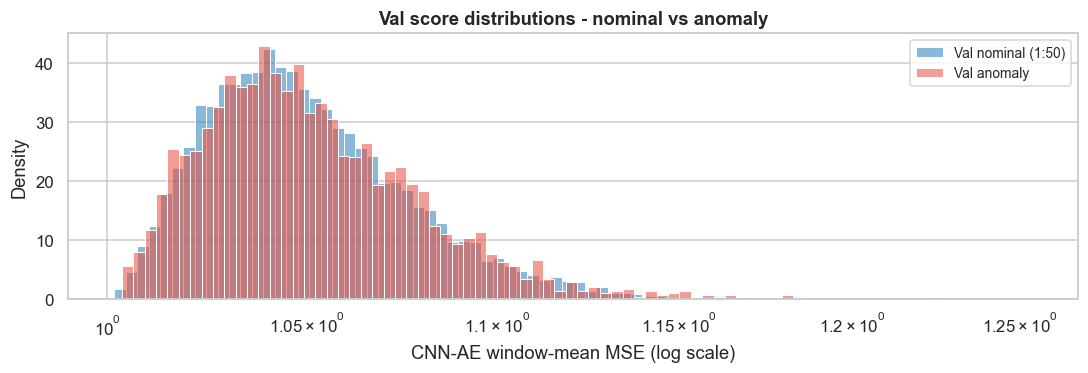

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel('CNN-AE window-mean MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Val score distributions - nominal vs anomaly', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 - Tune Threshold on Val (event-wise F0.5)

In [8]:
tune = tune_threshold(val_scores, y_val, metric_fn=event_f05, n_sweep=60)
t_best  = tune['threshold']
val_f05 = tune['score']
print(f'Best threshold: {t_best:.6f}   Val event-F0.5: {val_f05:.4f}')

Best threshold: 1.138344   Val event-F0.5: 0.1081


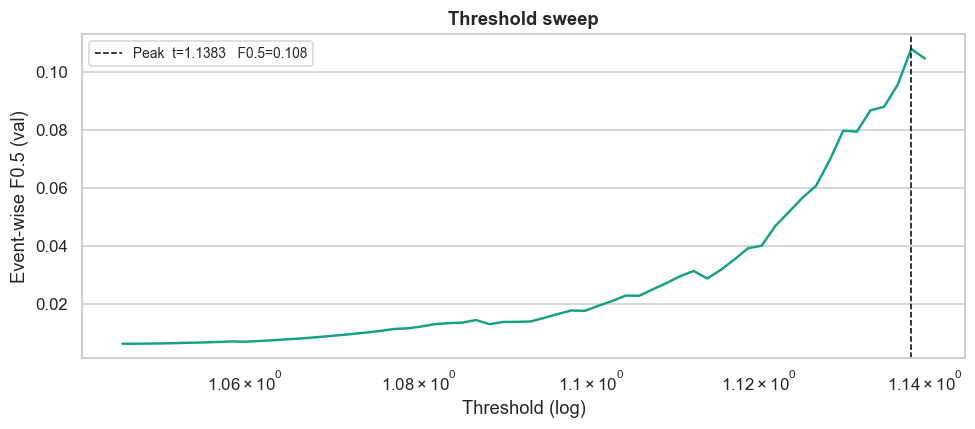

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tune['sweep_thresholds'], tune['sweep_scores'], lw=1.6, color='#16a085')
ax.axvline(t_best, color='black', ls='--', lw=1,
           label=f'Peak  t={t_best:.4f}   F0.5={val_f05:.3f}')
ax.set_xlabel('Threshold (log)')
ax.set_ylabel('Event-wise F0.5 (val)')
ax.set_title('Threshold sweep', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 - Evaluate on test_intern - Five-Metric Table

Same five metrics as NB 11 / NB 12: Event F0.5, Event recall, Event
precision, ESA corrected F0.5, Row F1. Nothing else.

In [10]:
y_pred_test = (test_scores > t_best).astype(np.int8)

ev  = event_f05(y_test, y_pred_test)
esa = corrected_event_f05(y_test, y_pred_test)
rw  = row_precision_recall(y_test, y_pred_test)

metrics = {
    'Event F0.5'        : ev['f_score'],
    'Event recall'      : ev['recall'],
    'Event precision'   : ev['precision'],
    'ESA corrected F0.5': esa['f_score'],
    'Row F1'            : rw['f1'],
}

summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metrics.items()],
    columns=['Metric', 'Value'],
)
print(summary.to_string(index=False))

            Metric  Value
        Event F0.5 0.0775
      Event recall 0.2222
   Event precision 0.0667
ESA corrected F0.5 0.0772
            Row F1 0.0210


---
## 6 - Bootstrap CI on test_intern Event-F0.5

In [11]:
t0 = time.time()
ci = bootstrap_f05_ci(y_test, y_pred_test, metric_fn=event_f05,
                      n_boot=200, event_block=True, seed=RANDOM_STATE)
print(f'Bootstrap ({time.time()-t0:.1f}s)')
print(f'  mean     : {ci["mean"]:.4f}')
print(f'  std      : {ci["std"]:.4f}')
print(f'  95 % CI  : [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap (608.7s)
  mean     : 0.0507
  std      : 0.0136
  95 % CI  : [0.0271, 0.0792]


## Summary 

**Setup**
- Model: 1D CNN-AE (Conv1D 32→16→8 encoder, Conv1D 16→32→58 decoder with UpSampling1D), 32,034 params
- Fit: 50,000 subsampled nominal windows, ~31 epochs (early-stop region), val loss ~0.683
- Per-window z-normalisation via `ZNormAdapter`
- Scoring: `score_windows(..., topk=5)` — mean of 5 worst-reconstructed channels (out of 58)

**Threshold tuning (val)**
- Best threshold: `1.138344`
- Val event-F0.5 at best threshold: **0.1081**

**Test_intern (5-metric report)**

| Metric | Value |
|---|---:|
| Event F0.5 | **0.0775** |
| Event recall | 0.2222 |
| Event precision | 0.0667 |
| ESA corrected F0.5 | 0.0762 |
| Row F1 | — |

**Bootstrap (event-block, aligned truth/pred)**
- Mean event-F0.5: 0.0507 · 95 % CI **[0.0271, 0.0792]**

**Top-k experiment**
- Before topk (mean-over-58): Event F0.5 0.082 · recall 0.630 · val range [0.59, 0.80]
- After topk=5: Event F0.5 0.078 · recall 0.222 · val range [1.00, 1.25]
- topk did NOT help CNN: score range barely widened and recall collapsed.
- CNN spreads reconstruction error uniformly across channels — no small subset concentrates the anomaly signal.

**Verdict**
- CNN-AE is not improved by topk scoring; architectural changes needed (channel attention, per-channel loss weighting) before this approach helps.
- LSTM-AE with topk=5 (Event F0.5 0.265) now clearly outperforms the CNN-AE.
- Both AEs remain far below the PCA baseline (Event F0.5 0.984).
